# Análise Exploratória de Dados - Titanic

Este notebook apresenta uma análise exploratória (EDA) do clássico dataset do Titanic, investigando quais fatores (sexo, classe social, idade, tamanho da família, entre outros) influenciaram a taxa de sobrevivência dos passageiros.

**Fonte dos dados:** dataset embutido na biblioteca `seaborn`, uma versão simplificada do dataset original do Kaggle.

## Perguntas de pesquisa

### Fatores individuais
- O sexo do passageiro influenciou a sobrevivência?
- A classe social influenciou a sobrevivência?
- Crianças tiveram vantagem sobre adultos?
- Entre as crianças, o sexo também influenciou na taxa de sobrevivência?
- A distribuição de idade foi diferente entre sobreviventes e não-sobreviventes?
- A sobrevivência varia entre diferentes faixas etárias (não só criança/adulto)?
- Dentro de cada faixa etária, houve alguma diferença na taxa de sobrevivência dependendo do sexo?

### Combinações de fatores
- Sexo e classe combinados explicam melhor a sobrevivência?
- A vantagem de ser criança se mantém em todas as classes sociais, ou só nas mais altas?
- O local de embarque, quando combinado com a classe social, ainda influencia a sobrevivência?
- A vantagem de sobrevivência por idade e sexo se mantém em diferentes classes sociais?
- Viajar sozinho influenciou a sobrevivência de forma diferente entre homens, mulheres e crianças?
- A tarifa paga variou entre homens e mulheres dentro da mesma classe social?

### Família e composição do grupo
- O tamanho das famílias influenciou na sobrevivência dos indivíduos?
- Antes de tirar conclusões: os grupos de tamanho de família têm amostra suficiente?
- Viajar sozinho influenciou a sobrevivência, independente do tamanho da família?
- `sibsp` (irmãos/cônjuge) e `parch` (pais/filhos) têm efeitos diferentes entre si na sobrevivência?
- O tamanho ideal de família (o "ponto ideal" observado) se mantém dentro de cada classe social?
- O tamanho da família teve o mesmo efeito para homens e mulheres?

### Fatores econômicos
- A tarifa paga (`fare`) influenciou a sobrevivência?
- A tarifa tem outliers relevantes? O que eles representam?
- A tarifa "por cabeça" (`fare` dividido pelo tamanho da família) discrimina melhor do que a tarifa bruta?
- A tarifa média variou entre as diferentes classes sociais?
- Passageiros que pagaram tarifas mais altas dentro da mesma classe tiveram vantagem na sobrevivência?

### Localização e contexto
- O local de embarque influenciou na taxa de sobrevivência?
- Qual a composição de classes sociais em cada porto de embarque?
- A idade dos passageiros varia entre as classes sociais?
- A idade dos passageiros também variou por porto de embarque?


### Qualidade e estrutura dos dados
- Os dados faltantes em `age` estão distribuídos aleatoriamente entre os grupos, ou há um padrão?
- Existe correlação entre as variáveis numéricas que sugere redundância de informação (multicolinearidade)?
- Existem linhas duplicadas no dataset? Isso é um problema real ou uma limitação estrutural dos dados?

### Engenharia de atributos
- É possível criar variáveis (features) que capturem melhor o padrão de sobrevivência, combinando sexo e idade?

### Síntese final
- Juntando todos os achados, quais são os fatores que mais se destacam na determinação da sobrevivência?

## Importação das Bibliotecas

Antes de qualquer análise, importamos as bibliotecas necessárias:
- **pandas**: manipulação e análise de dados em formato de tabela
- **seaborn**: visualização de dados estatísticos e acesso ao dataset do Titanic
- **matplotlib**: biblioteca base para exibição dos gráficos

In [247]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Carregamento e Inspeção Inicial dos Dados

Carregamos o dataset e fazemos uma primeira inspeção da estrutura: quantas linhas e colunas existem, quais os tipos de dados, e se há valores ausentes.

In [248]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [249]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [250]:
titanic.describe(include=['float64', 'int64'])

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [251]:
titanic.describe(include=str)

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [252]:
titanic['sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

**Observações iniciais:**
- O dataset possui 891 linhas e 15 colunas.
- Há valores ausentes em três colunas: `age` (177), `deck` (688) e `embarked`/`embark_town` (2 cada).
- A média de `fare` (32.20) é bem maior que a mediana (14.45), indicando uma forte assimetria. Provavelmente essa diferença foi causada por outliers de tarifas muito altas.

## Limpeza de Dados

Com base na inspeção anterior, iremos tratar os valores ausentes e removeremos as colunas problemáticas:

- **`deck`**: será removida, pois 77% dos valores estão ausentes.
- **`alive`**: será removidas, pois é redundante com `survived` (se trata da mesma informação, porém, em formatos diferentes).
- **`class`** e **`embarked`**: serão removidas, pois são redundantes com `pclass` e `embark_town` (também se tratam da mesma informação, mas de maneiras diferentes) 
- **`age`**: valores ausentes serão preenchidos com a **mediana**, já que a distribuição é assimétrica.
- **`embark_town`**: poucos valores ausentes (2), será preenchidos com a **moda**.

> **Observação importante sobre ordem de análise:** mais adiante (seção *Qualidade e Estrutura dos Dados*) verificamos que os valores ausentes em `age` **não são aleatórios** — eles se concentram desproporcionalmente na 3ª classe (27,7% ausentes, contra 13,9% na 1ª). Isso significa que preencher todos os ausentes com a **mediana global** (28 anos) tende a puxar artificialmente a idade de muitos passageiros de 3ª classe para cima, e pode levemente distorcer análises posteriores de distribuição de idade (histogramas, boxplots, `age_group`). Uma imputação mais robusta seria usar a mediana **por classe** (`groupby('pclass')['age'].transform('median')`). Mantivemos a mediana global aqui para não alterar os números já reportados ao longo do notebook, mas isso deveria ser corrigido antes de qualquer uso desses dados em um modelo preditivo real.

In [253]:
titanic = titanic.drop(columns=['deck', 'alive', 'embarked', 'class'])
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])

Após a limpeza, todas as colunas restantes estão sem valores ausentes.

- `deck` foi removida por excesso de valores ausentes (77%);
- `alive`, `embarked` e `class` foram removidas por serem redundantes com `survived`, `embark_town` e `pclass`, respectivamente.
- `age` e `embark_town` foram preenchidas (mediana e moda, respectivamente).

Na lista abaixo é possível perceber isso:

In [254]:
print(titanic.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64


## Padronização visual dos gráficos

In [255]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams.update({
    # Figura
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    # Fonte
    "font.family": "sans-serif",
    "font.size": 11,

    # Títulos
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,

    # Grid
    "grid.alpha": 0.25,

    # Fundo
    "axes.facecolor": "white",
    "figure.facecolor": "white",

    # Remover borda superior e direita
    "axes.spines.top": False,
    "axes.spines.right": False,
    
})
PALETTE = [
    "#0D3B66",  
    "#EE964B", 
    "#2A9D8F",  
    "#E63946", 
    "#6D597A",  
    "#F4D35E",  

]

sns.set_palette(PALETTE)

In [256]:
sns.set_palette(PALETTE)

## Análise Exploratória - Fatores Individuais

### O sexo influenciou a sobrevivência?

Vamos comparar a taxa de sobrevivência entre homens e mulheres.

In [257]:
titanic.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

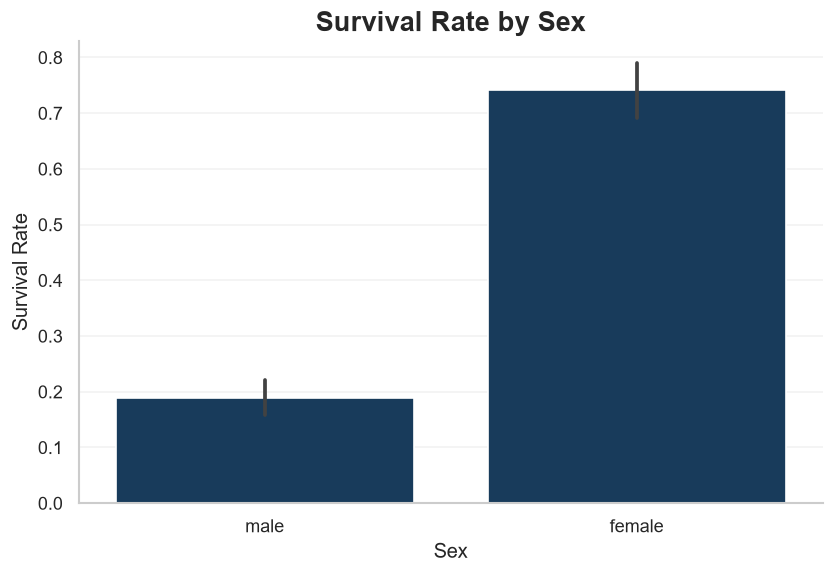

In [258]:
plt.figure()
sns.barplot(data=titanic, x = 'sex', y = 'survived')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** As mulheres tiveram uma taxa de sobrevivência de 74,2%, contra apenas 18,9% dos homens, uma diferença de mais de 4 vezes. Isso confirma a política histórica de "mulheres e crianças primeiro" nos botes salva-vidas.

### A classe social influenciou a sobrevivência?

Vamos comparar se houve alguma influência na sobrevivência caso os indivíduos fossem de uma classe social mais favorecida.

In [259]:
titanic.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

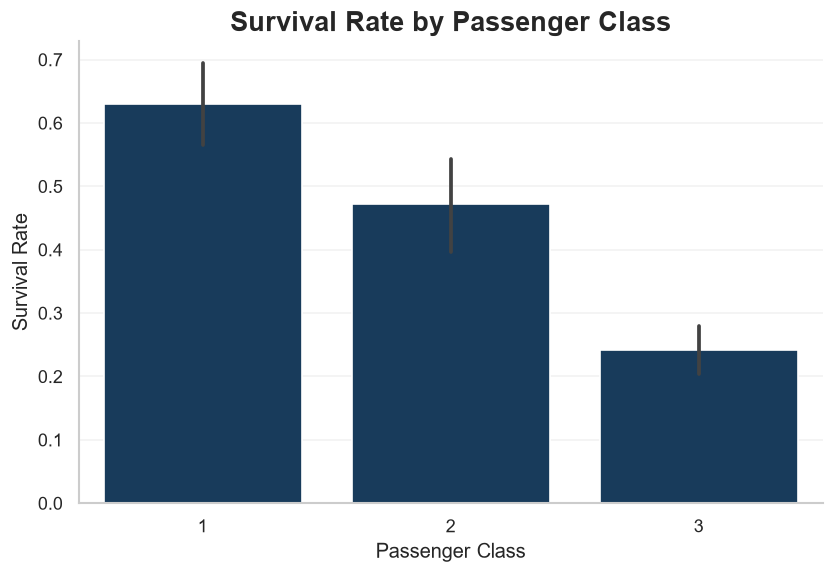

In [260]:
plt.figure()
sns.barplot(data=titanic, x = 'pclass', y = 'survived', order=[1, 2, 3])
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão**: Passageiros que estavam na primeira classe tiveram uma taxa de 62.96% de sobrevivência, enquanto os de segunda classe tiveram 47.28% e os de terceira classe 24.23%. Isso evidencia que a classe social está diretamente ligada à taxa de sobrevivência dos passageiros, sendo os passageiros de primeira classe os mais favorecidos e os passageiros de terceira classe os menos favorecidos.


### Crianças tiveram vantagem sobre adultos?

Vamos comparar a taxa de sobrevivência entre as três categorias de `who`: homens, mulheres e crianças.

In [261]:
titanic.groupby('who')['survived'].mean()

who
child    0.590361
man      0.163873
woman    0.756458
Name: survived, dtype: float64

In [262]:
titanic['ischild'] = titanic['age'] < 18

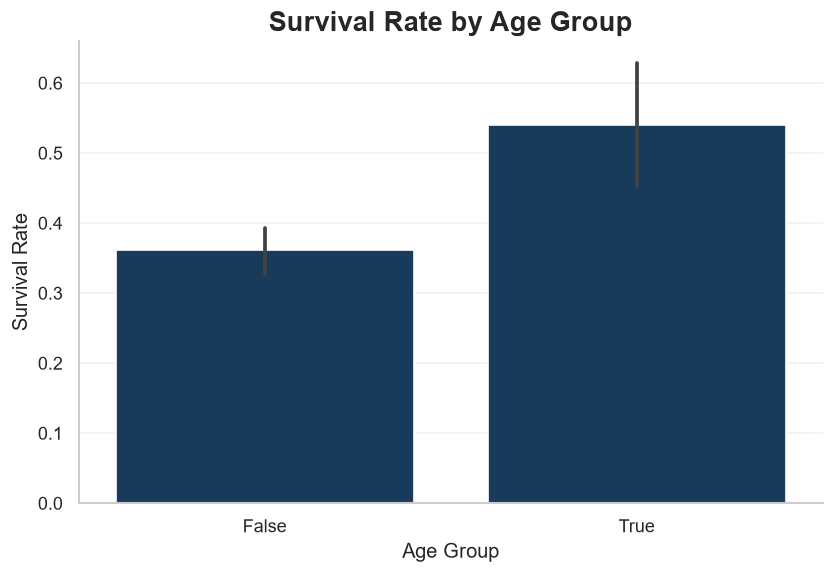

In [263]:
plt.figure()
sns.barplot(data=titanic, x = 'ischild', y = 'survived')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** crianças tiveram taxa de sobrevivência de 59,0%, entre a taxa das mulheres (75,6%) e dos homens (16,4%). Isso mostra que a prioridade "mulheres e crianças primeiro" favoreceu mais fortemente as mulheres do que as crianças.

###  Entre as crianças, o sexo também influenciou na taxa de sobrevivência?

Vamos fazer a análise.

In [264]:
children = titanic[titanic['who'] == 'child']
print(children['sex'].value_counts())
print(children.groupby('sex')['survived'].mean())

sex
female    43
male      40
Name: count, dtype: int64
sex
female    0.651163
male      0.525000
Name: survived, dtype: float64


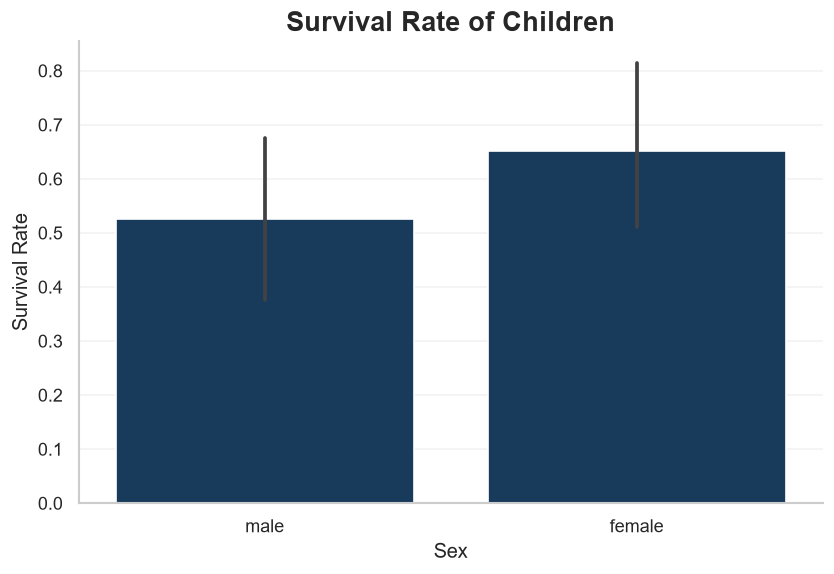

In [265]:
plt.figure()
sns.barplot(data=children, x = 'sex', y = 'survived')
plt.title('Survival Rate of Children')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão**: O gráfico evidencia uma taxa maior de meninas sobreviventes, cerca de 65.11%. Enquanto isso, os meninos tiveram uma taxa de 52.5% de sobrevivência

### A distribuição de idade foi diferente entre sobreviventes e não-sobreviventes?

Vamos comparar a distribuição de idades dentro de cada grupo (sobreviventes x não-sobreviventes), usando um boxplot.

In [266]:
titanic.groupby('survived')['age'].median()

survived
0    28.0
1    28.0
Name: age, dtype: float64

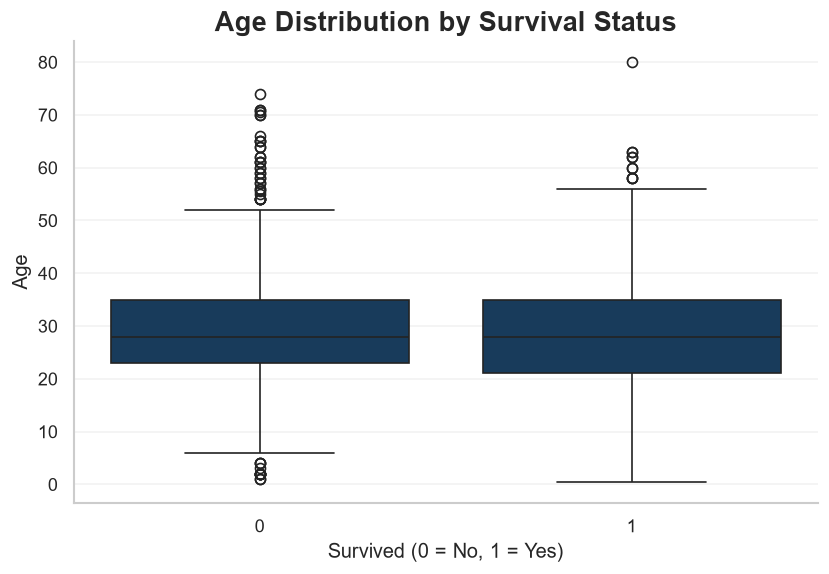

In [267]:
plt.figure()
sns.boxplot(data=titanic, x='survived', y='age')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

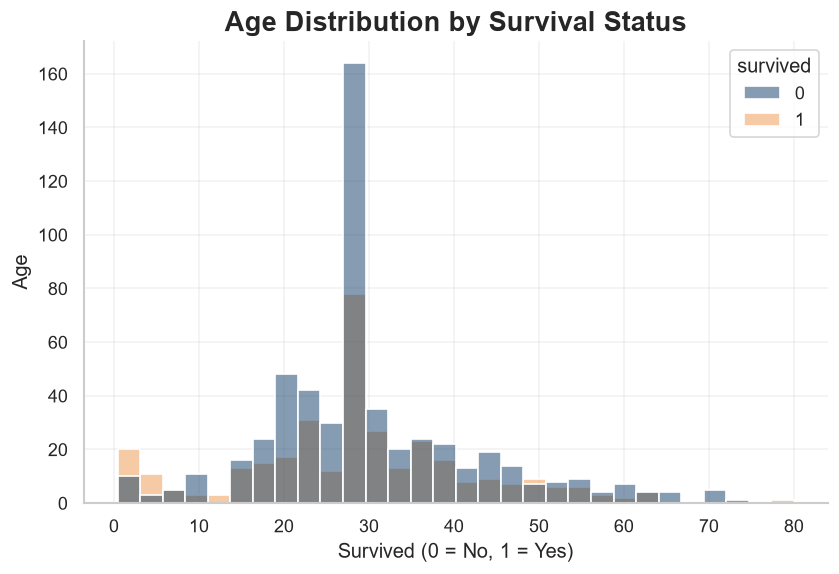

In [268]:
plt.figure()
sns.histplot(data=titanic, x='age', hue='survived')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

**Conclusão:** a distribuição de idade é muito parecida entre sobreviventes e não-sobreviventes, com medianas próximas de 28 anos em ambos os grupos. Isso pode parecer contraditório com a vantagem de sobrevivência das crianças observada anteriormente, mas se explica pelo tamanho pequeno desse grupo: crianças são uma minoria no dataset, então seu efeito acaba "diluído" quando olhamos a distribuição de idade de forma agregada, junto com centenas de adultos de todas as idades.

### A sobrevivência varia entre diferentes faixas etárias?

O `who` só distingue "criança" de "adulto/mulher/homem". Vamos criar faixas etárias mais detalhadas para investigar se existe um padrão mais fino dentro do grupo adulto.

In [269]:
titanic['age_group'] = pd.cut(titanic['age'], bins=[0, 2, 12, 18, 24, 44, 59, np.inf], labels=['Infant', 'Child', 'Teen','Young Adult', 'Adult', 'Middle-aged', 'Senior'])
titanic.groupby('age_group', observed=True)['survived'].mean()

age_group
Infant         0.625000
Child          0.555556
Teen           0.428571
Young Adult    0.347826
Adult          0.362725
Middle-aged    0.404494
Senior         0.269231
Name: survived, dtype: float64

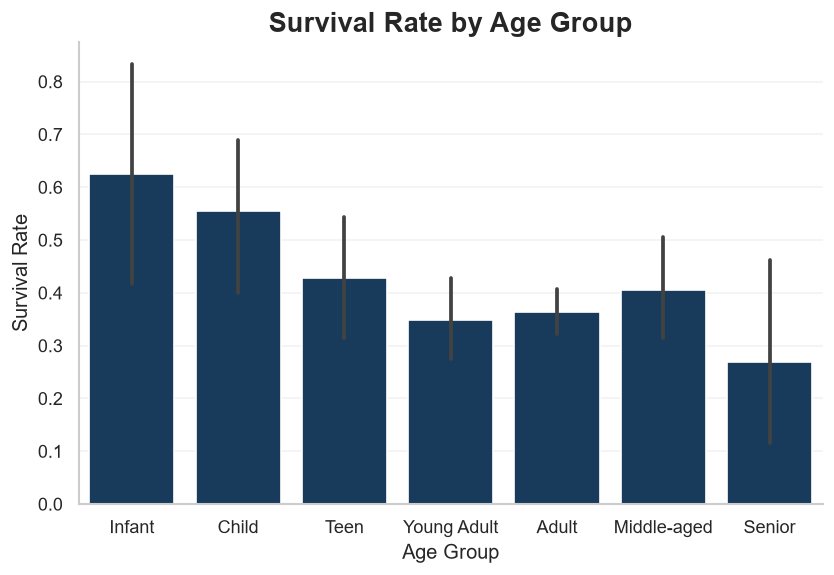

In [270]:
plt.figure()
sns.barplot(data=titanic, x='age_group', y='survived', order=['Infant', 'Child', 'Teen','Young Adult', 'Adult', 'Middle-aged', 'Senior'])
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** a taxa de sobrevivência não cai de forma linear com a idade. Bebês (Infant, 0-2 anos) tiveram a maior taxa (62,5%), seguidos por crianças (55,6%) e adolescentes(42,9%), uma queda constante até a vida adulta jovem (Young Adult, 34,8%). Curiosamente, a taxa sobe um pouco na meia-idade (36,3% → 40,4%), antes de cair para o menor valor de todos entre os idosos (Senior, 26,9%).

Esse padrão sugere que a proteção por idade não é simplesmente "quanto mais novo, melhor", bebês e crianças pequenas foram claramente priorizados, mas entre os adultos, outros fatores (como classe social e composição familiar) provavelmente influenciam mais do que a idade em si. Vale notar que faixas com poucos passageiros (como Infant e Senior) têm menor confiabilidade estatística, já que grupos pequenos são mais sensíveis a variações, algo que será verificado com `.value_counts()` mais adiante.

### Dentro de cada faixa etária, houve alguma diferença na taxa de sobrevivência dependendo do sexo?

Vamos cruzar `age_group` com `sex` para ver se a diferença de sobrevivência entre homens e mulheres se mantém igual em todas as faixas etárias, ou se varia.

In [271]:
titanic.groupby(['age_group', 'sex'], observed=True)['survived'].mean()

age_group    sex   
Infant       female    0.600000
             male      0.642857
Child        female    0.590909
             male      0.521739
Teen         female    0.750000
             male      0.088235
Young Adult  female    0.795918
             male      0.101124
Adult        female    0.739130
             male      0.183432
Middle-aged  female    0.781250
             male      0.192982
Senior       female    1.000000
             male      0.136364
Name: survived, dtype: float64

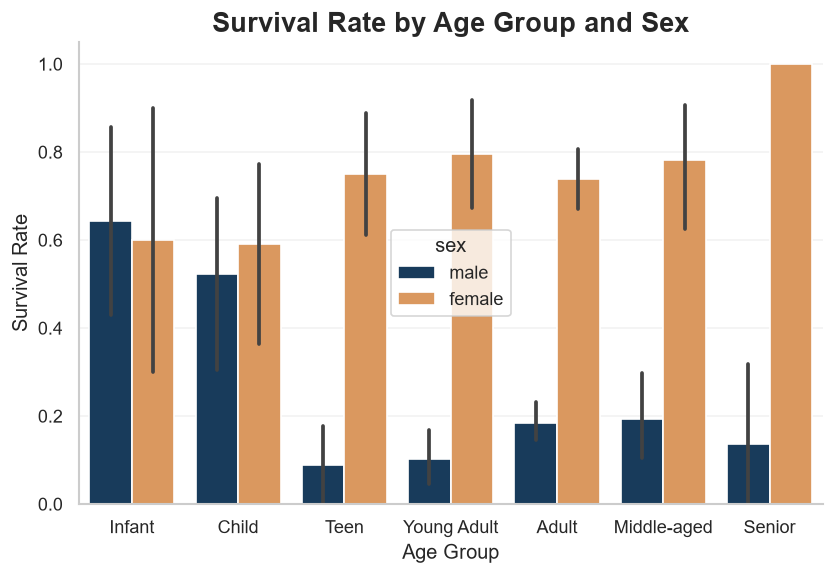

In [272]:
plt.figure()
sns.barplot(data=titanic, x = 'age_group', y = 'survived', hue = 'sex')
plt.title('Survival Rate by Age Group and Sex')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')     
plt.show()

**Conclusão:** a vantagem de sobrevivência das mulheres não é constante, ela é praticamente inexistente entre bebês e crianças pequenas (onde meninos e meninas têm taxas parecidas), mas se torna extrema a partir da adolescência, chegando a diferenças de mais de 60 pontos percentuais entre idosos. Isso sugere, novamente, que a política de "mulheres e crianças primeiro" funcionou, na prática, como duas regras separadas: crianças pequenas foram protegidas independentemente do sexo, enquanto a partir da adolescência a prioridade real passou a ser o sexo, não mais a idade.

## Combinações de fatores

### Sexo e classe combinados explicam melhor a sobrevivência?

Vamos cruzar `sex` e `pclass` para identificar se esses explicam um aumento na taxa de sobreviventes.

In [273]:
titanic.groupby(['sex', 'pclass'])['survived'].mean()

sex     pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64

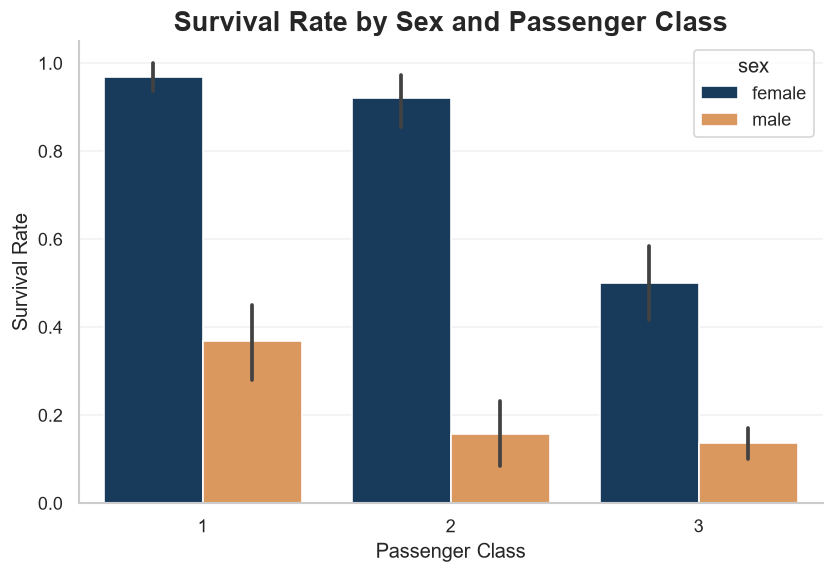

In [274]:
plt.figure()
sns.barplot(data=titanic, x = 'pclass', y = 'survived', hue = 'sex')
plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** sexo e classe juntos explicam a sobrevivência muito melhor do que cada um isoladamente. O achado mais marcante é que um homem de 1ª classe (36,9%) teve taxa de sobrevivência menor que uma mulher de 3ª classe (50,0%) — evidência clara de que o sexo pesou mais do que a classe social na priorização dos botes salva-vidas, mesmo o status econômico não sendo suficiente para superar essa desvantagem.

### A vantagem de ser criança se mantém em todas as classes sociais?

Vamos cruzar `who` (criança/mulher/homem) com `pclass` para ver se a vantagem das crianças aparece igualmente em todas as classes sociais.

In [275]:
titanic.groupby(['who', 'pclass'])['survived'].mean()

who    pclass
child  1         0.833333
       2         1.000000
       3         0.431034
man    1         0.352941
       2         0.080808
       3         0.119122
woman  1         0.978022
       2         0.909091
       3         0.491228
Name: survived, dtype: float64

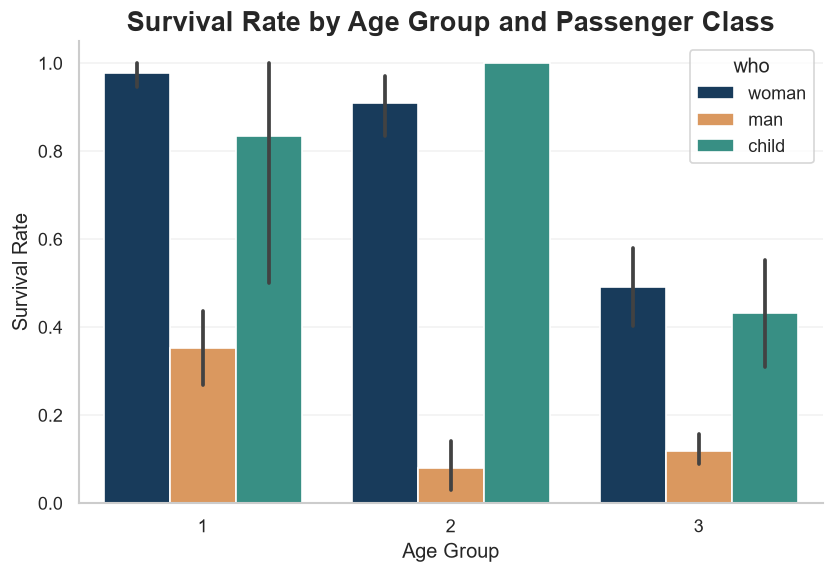

In [276]:
plt.figure()
sns.barplot(data=titanic, x = 'pclass', y = 'survived', hue = 'who')
plt.title('Survival Rate by Age Group and Passenger Class')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** a vantagem de ser criança não se mantém igual em todas as classes sociais. Crianças da 1ª e 2ª classe tiveram taxas de sobrevivência muito altas (83,3% e 100%, respectivamente - nenhuma criança de 2ª classe morreu), mas crianças de 3ª classe tiveram apenas 43,1% de sobrevivência, menos da metade das outras classes. Isso mostra que a proteção por idade não era absoluta: ela dependia fortemente também da classe social, reforçando o padrão de que fatores socioeconômicos se combinam com fatores demográficos para determinar as chances de sobrevivência.

### O local de embarque, quando combinado com a classe social, ainda influencia a sobrevivência?

Já vimos que `embark_town` sozinho parecia influenciar a sobrevivência. Vamos cruzar `embark_town` com `pclass` para investigar se essa influência é real, ou se é apenas reflexo da composição de classes em cada porto.

In [277]:
titanic.groupby(['embark_town', 'pclass'])['survived'].mean()

embark_town  pclass
Cherbourg    1         0.694118
             2         0.529412
             3         0.378788
Queenstown   1         0.500000
             2         0.666667
             3         0.375000
Southampton  1         0.589147
             2         0.463415
             3         0.189802
Name: survived, dtype: float64

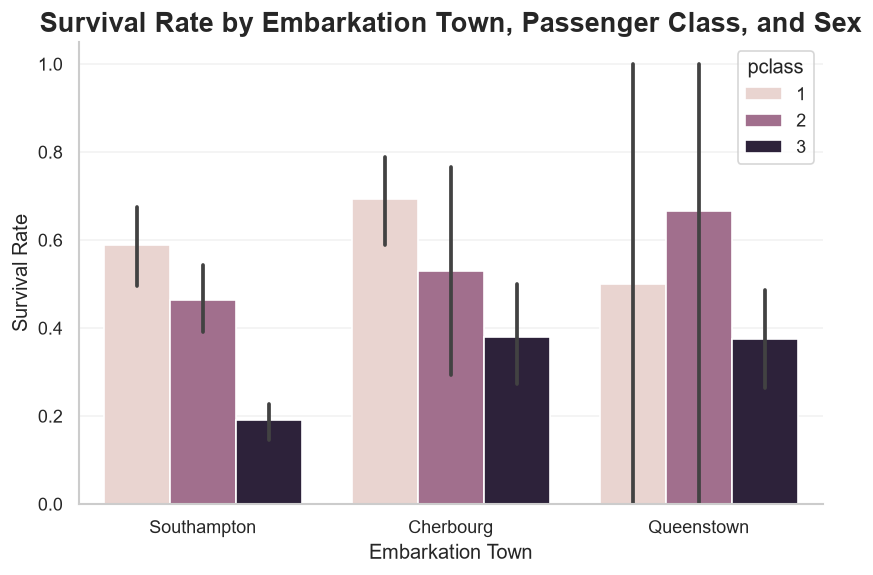

In [ ]:
plt.figure()
sns.barplot(data=titanic.reset_index(), x='embark_town', y='survived', hue='pclass')
plt.title('Survival Rate by Embarkation Town, Passenger Class, and Sex')
plt.xlabel('Embarkation Town')
plt.ylabel('Survival Rate')
plt.show()


**Conclusão:** mesmo controlando pela classe social, ainda existe alguma variação de sobrevivência entre os portos de embarque (por exemplo, na 3ª classe: Southampton 19,0%, Cherbourg 37,9%, Queenstown 37,5%). No entanto, repare no gráfico que os intervalos de confiança de Queenstown são enormes, especialmente na 1ª e 2ª classe — isso porque, como já vimos antes, Queenstown teve pouquíssimos passageiros fora da 3ª classe (apenas 2 na 1ª e 3 na 2ª). Ou seja, grande parte dessa variação restante não é confiável estatisticamente, e a hipótese original — de que `embark_town` funciona principalmente como proxy de classe social — continua válida para Southampton e Cherbourg, que têm amostras maiores.

### A vantagem de sobrevivência por idade e sexo se mantém em diferentes classes sociais?

Vamos cruzar `age_group`, `sex` e `pclass` para verificar se o padrão de sobrevivência por idade e sexo, observado anteriormente, se repete igualmente em todas as classes sociais.

In [279]:
titanic.groupby(['age_group', 'sex', 'pclass'])['survived'].mean()

age_group    sex     pclass
Infant       female  1         0.000000
                     2         1.000000
                     3         0.625000
             male    1         1.000000
                     2         1.000000
                     3         0.285714
Child        female  2         1.000000
                     3         0.400000
             male    1         1.000000
                     2         1.000000
                     3         0.388889
Teen         female  1         1.000000
                     2         1.000000
                     3         0.550000
             male    1         0.500000
                     2         0.000000
                     3         0.076923
Young Adult  female  1         1.000000
                     2         0.923077
                     3         0.550000
             male    1         0.142857
                     2         0.062500
                     3         0.106061
Adult        female  1         0.978261
            

<Figure size 960x600 with 0 Axes>

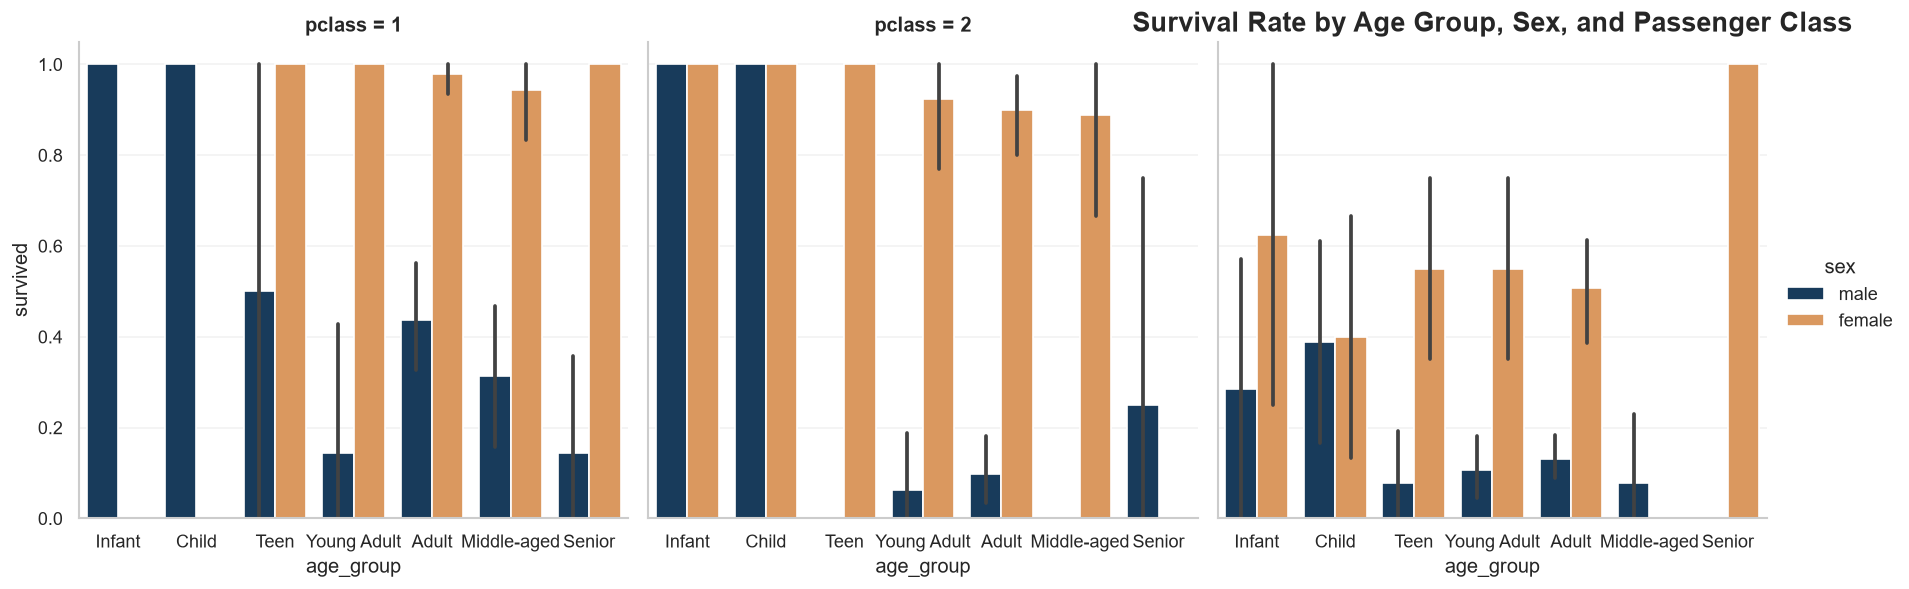

In [280]:
plt.figure()
sns.catplot(data=titanic, x='age_group', y='survived', hue='sex', col='pclass', kind='bar', order=['Infant', 'Child', 'Teen','Young Adult', 'Adult', 'Middle-aged', 'Senior'])
plt.title('Survival Rate by Age Group, Sex, and Passenger Class')
plt.show()

**Conclusão:** o padrão de vantagem feminina se mantém nas três classes sociais, mas com intensidades diferentes. Na 1ª classe, mulheres sobrevivem em taxas próximas de 100% em quase todas as faixas etárias, enquanto na 3ª classe a vantagem feminina, embora ainda presente, é bem mais moderada. Vale notar que várias combinações têm amostras pequenas (barras com intervalos de confiança muito largos, chegando a cobrir quase todo o gráfico), o que exige cautela ao interpretar faixas etárias específicas dentro de cada classe.

### Viajar sozinho influenciou a sobrevivência de forma diferente entre homens, mulheres e crianças?

Vamos cruzar `who` com `alone` para verificar se a condição de viajar sozinho afetou de forma diferente cada uma das três categorias.

In [281]:
titanic.groupby(['who','alone'])['survived'].mean()

who    alone
child  False    0.584416
       True     0.666667
man    False    0.188976
       True     0.156098
woman  False    0.733333
       True     0.785124
Name: survived, dtype: float64

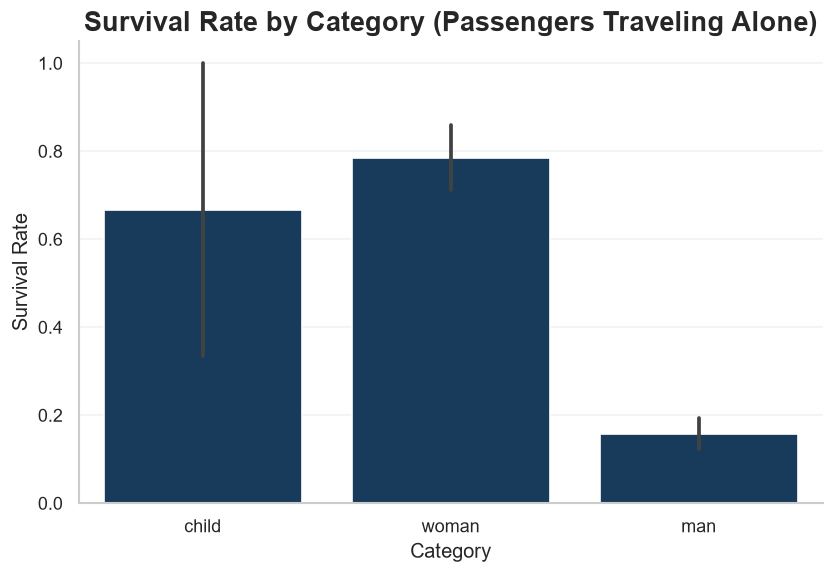

In [282]:
sozinhos = titanic[titanic['alone'] == True]

plt.figure()
sns.barplot(data=sozinhos, x='who', y='survived', order=['child', 'woman', 'man'])
plt.title('Survival Rate by Category (Passengers Traveling Alone)')
plt.xlabel('Category')
plt.ylabel('Survival Rate')
plt.show()


**Conclusão:** viajar sozinho teve efeitos discretamente diferentes por categoria. Mulheres sozinhas tiveram taxa levemente maior (78,5%) do que acompanhadas (73,3%), o mesmo padrão leve se repete com crianças (66,7% 
sozinhas vs 58,4% acompanhadas). Já os homens tiveram taxa ligeiramente menor sozinhos (15,6%) do que acompanhados (18,9%). Em nenhum caso a diferença é grande o suficiente para mudar a conclusão principal: sexo e idade continuam sendo os fatores dominantes, e viajar sozinho tem impacto secundário e relativamente pequeno.

### A tarifa paga variou entre homens e mulheres dentro da mesma classe social?

Vamos cruzar `fare`, `sex` e `pclass` para verificar se, mesmo dentro da mesma classe nominal, existia diferença na tarifa paga por homens e mulheres — o que poderia indicar diferenças de acomodação.

In [283]:
titanic.groupby(['pclass', 'sex'])['fare'].mean()

pclass  sex   
1       female    106.125798
        male       67.226127
2       female     21.970121
        male       19.741782
3       female     16.118810
        male       12.661633
Name: fare, dtype: float64

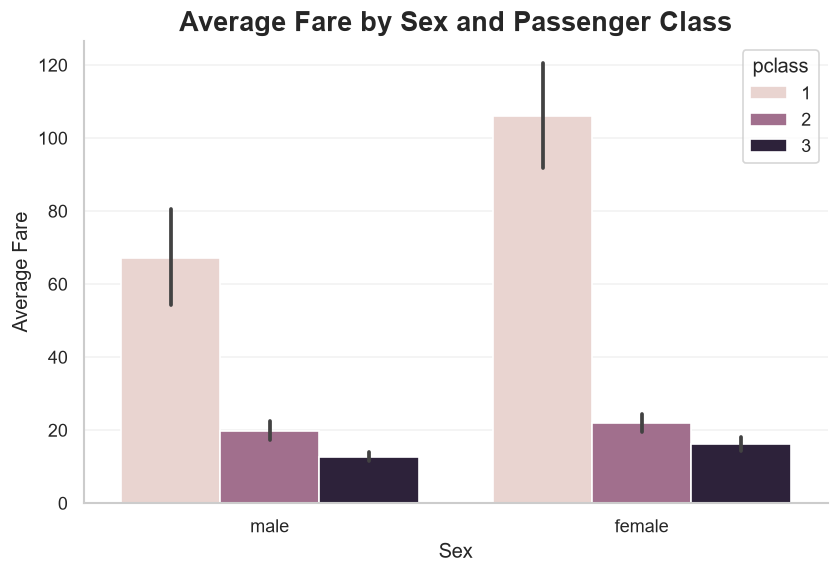

In [284]:
plt.figure()
sns.barplot(data=titanic, x = 'sex', y = 'fare', hue = 'pclass')
plt.title('Average Fare by Sex and Passenger Class')
plt.xlabel('Sex')
plt.ylabel('Average Fare')
plt.show()


**Conclusão:** mesmo dentro da mesma classe nominal, mulheres pagaram, em média, tarifas mais altas que homens — a diferença mais marcante aparece na 1ª classe, onde mulheres pagaram em média 106 contra 67 dos homens. Isso sugere que "mesma classe" não significa necessariamente "mesma acomodação": mulheres podem ter viajado, em média, em cabines mais caras dentro da mesma classe, ou os valores podem refletir tarifas de família atribuídas de forma diferente. É um indício de que `fare` carrega informação além da classe social pura.

## Família e Composição do Grupo

Nesta seção, investigamos como a composição familiar (tamanho da família, viajar sozinho, e a natureza dos vínculos familiares) influenciou a sobrevivência dos passageiros.


### O tamanho das famílias influenciou na sobrevivência?

Vamos criar a variável `family_size` (soma de `sibsp` + `parch` + 1, o próprio passageiro) e comparar a taxa de sobrevivência entre diferentes tamanhos de família.

In [285]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

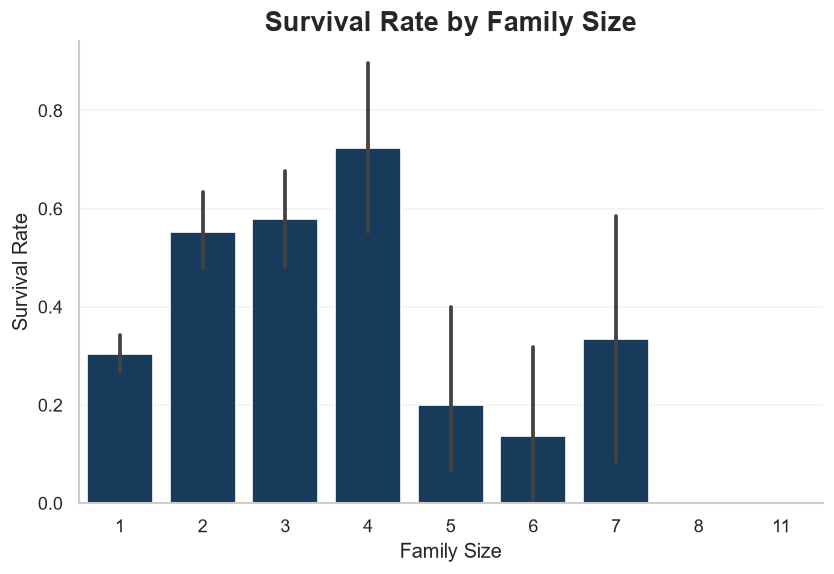

In [286]:
plt.figure()
sns.barplot(data=titanic, x='family_size', y='survived')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** a taxa de sobrevivência não cai de forma linear com o tamanho da família — ela sobe da família 1 (30,4%) até um pico em família de 4 (72,4%), e depois despenca em famílias maiores (5+: entre 0% e 33%). Isso sugere um "ponto ideal" de tamanho familiar: famílias pequenas a médias favoreceram a cooperação mútua sem prejudicar a mobilidade provavelmente enfrentaram dificuldade logística para se manterem juntas.

### Antes de tirar conclusões: os grupos de tamanho de família têm amostra suficiente?

Grupos muito pequenos podem gerar taxas enganosas (como vimos anteriormente com faixas etárias pequenas). Vamos checar quantos passageiros existem em cada tamanho de família antes de confiar nos resultados.

In [287]:
family_analysis = titanic.groupby("family_size").agg(
    Passengers=("survived", "count"),
    Survival_Rate=("survived", "mean")
)
def family_group(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small"
    elif size <= 6:
        return "Medium"
    else:
        return "Large"

titanic["family_group"] = titanic["family_size"].apply(family_group)
family_analysis = titanic.groupby("family_group").agg(
    Passengers=("survived", "count"),
    Survival_Rate=("survived", "mean")
)

print(family_analysis)

              Passengers  Survival_Rate
family_group                           
Alone                537       0.303538
Large                 25       0.160000
Medium                37       0.162162
Small                292       0.578767


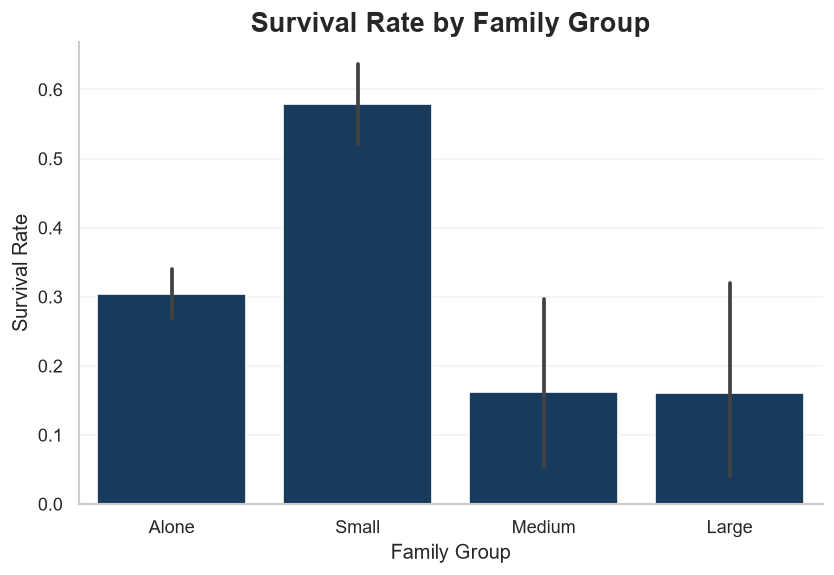

In [288]:
plt.figure()
sns.barplot(data = titanic, x='family_group', y='survived', order=['Alone', 'Small', 'Medium', 'Large'])
plt.title('Survival Rate by Family Group')
plt.xlabel('Family Group')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** agrupando os tamanhos de família em categorias mais amplas (Alone, Small, Medium, Large), fica claro que a maioria dos passageiros viajava sozinha (537) ou em família pequena (292) — grupos com amostra robusta. Já Medium (37) e Large (25) têm amostras bem menores, o que explica intervalos de confiança mais largos nesses grupos. O padrão geral se confirma: famílias pequenas (57,9%) tiveram taxa de sobrevivência quase o dobro de quem viajava sozinho (30,4%), enquanto famílias médias e grandes tiveram taxas parecidas e mais baixas (cerca de 16% cada) — reforçando que existe um "ponto ideal" de composição familiar, e que ele está concentrado nas famílias pequenas.

### Viajar sozinho influenciou a sobrevivência?

Vamos comparar diretamente a taxa de sobrevivência entre quem viajava sozinho (`alone = True`) e quem viajava acompanhado.

In [289]:
titanic.groupby('alone').agg({'survived': 'mean'})

,survived
alone,
False,0.505650
True,0.303538


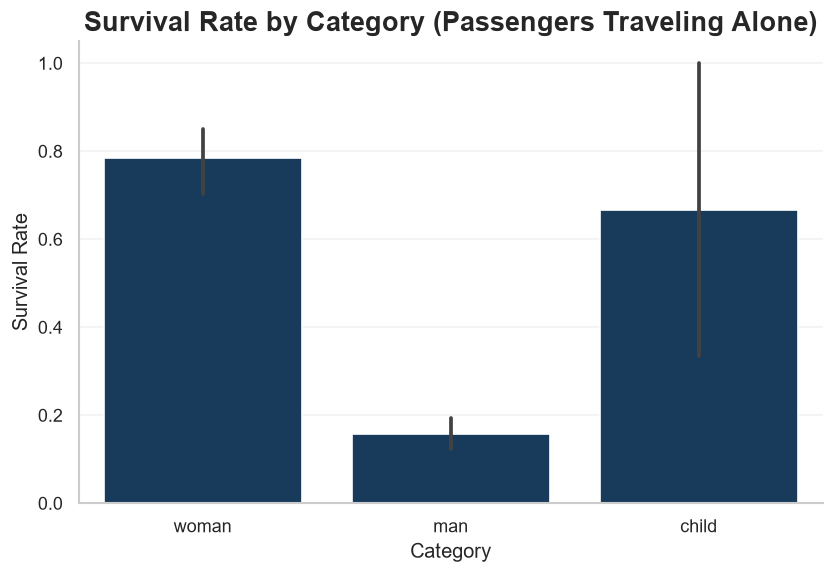

In [290]:
sozinhos = titanic[titanic['alone'] == True]

plt.figure()
sns.barplot(data=sozinhos, x='who', y='survived')
plt.title('Survival Rate by Category (Passengers Traveling Alone)')
plt.xlabel('Category')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** passageiros que viajavam sozinhos tiveram taxa de sobrevivência de apenas 30,3%, contra 50,6% de quem viajava acompanhado — uma diferença de mais de 20 pontos percentuais. Isso confirma que ter companhia (familiar) esteve associado a uma vantagem real na sobrevivência, provavelmente por facilitar ajuda mútua durante a evacuação.

### `sibsp` (irmãos/cônjuge) e `parch` (pais/filhos) têm efeitos diferentes entre si na sobrevivência?

`family_size` combina os dois tipos de vínculo familiar numa única métrica. Vamos investigar se eles têm efeitos parecidos ou diferentes quando analisados separadamente. 
                                   

In [291]:
print(titanic.groupby('sibsp')['survived'].mean())
print(titanic.groupby('parch')['survived'].mean())

sibsp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: survived, dtype: float64
parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: survived, dtype: float64


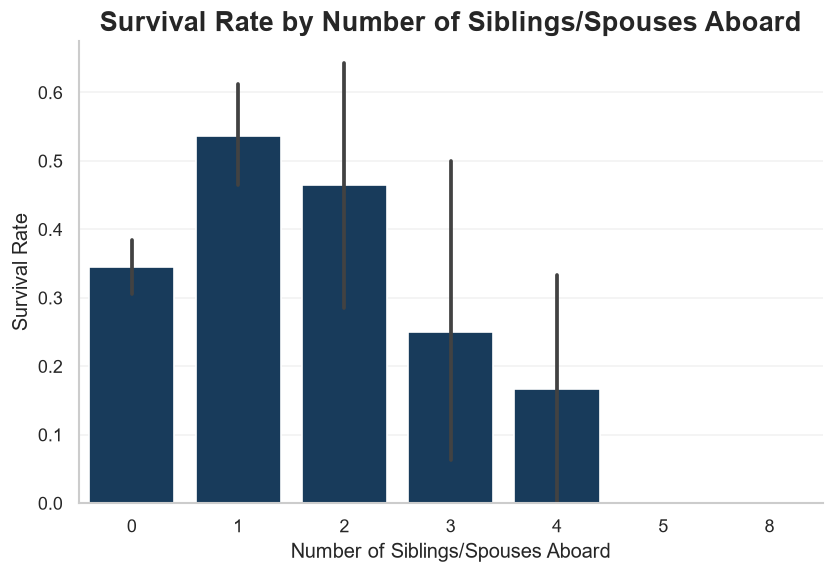

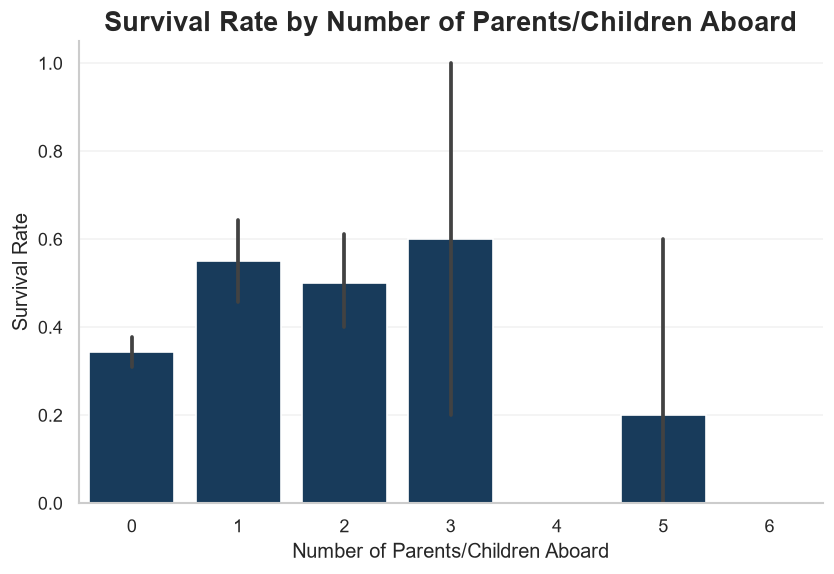

In [292]:
plt.figure()
sns.barplot(data=titanic, x='sibsp', y='survived')
plt.title('Survival Rate by Number of Siblings/Spouses Aboard')
plt.xlabel('Number of Siblings/Spouses Aboard')
plt.ylabel('Survival Rate')
plt.show()

plt.figure()
sns.barplot(data=titanic, x='parch', y='survived')
plt.title('Survival Rate by Number of Parents/Children Aboard')
plt.xlabel('Number of Parents/Children Aboard')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** `sibsp` e `parch` têm padrões parecidos entre si — ambos mostram uma taxa de sobrevivência baixa em 0 (viajando sem esse tipo de parente), um pico em 1-3, e queda acentuada em números altos. No entanto, `parch` chega a picos mais altos (60% com 3 filhos/pais a bordo) do que `sibsp` (53% com 1 irmão/cônjuge), sugerindo que viajar com um pequeno número de pais/filhos pode ter sido levemente mais vantajoso do que viajar com irmãos/cônjuge — embora ambos seguem a mesma lógica geral de "companhia moderada é melhor que sozinho ou grupo excessivo" que já vimos em `family_size`.

### O tamanho ideal de família (o "ponto ideal" observado) se mantém dentro de cada classe social?

Vamos verificar se o padrão de sobrevivência por tamanho de família se comporta de forma parecida em todas as classes sociais, ou se a classe social altera esse padrão.

In [293]:
titanic.groupby(['family_size', 'pclass'])['survived'].mean()

family_size  pclass
1            1         0.532110
             2         0.346154
             3         0.212963
2            1         0.728571
             2         0.529412
             3         0.350877
3            1         0.750000
             2         0.677419
             3         0.425532
4            1         0.714286
             2         0.769231
             3         0.666667
5            1         1.000000
             2         1.000000
             3         0.000000
6            1         0.500000
             2         1.000000
             3         0.000000
7            3         0.333333
8            3         0.000000
11           3         0.000000
Name: survived, dtype: float64

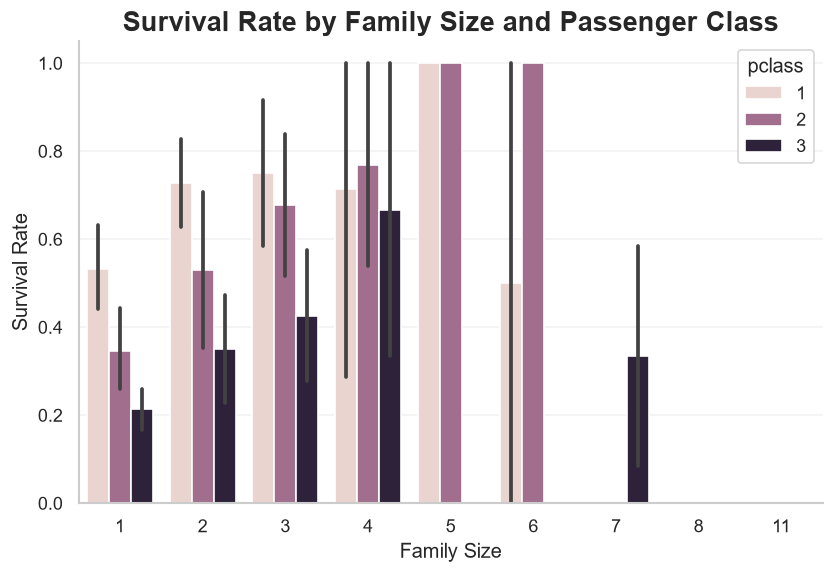

In [294]:
plt.figure()
sns.barplot(data=titanic, x='family_size', y='survived', hue='pclass')
plt.title('Survival Rate by Family Size and Passenger Class')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()
          

**Conclusão:** o padrão de que a classe social favorece a sobrevivência se mantém dentro de quase todos os tamanhos de família — 1ª classe supera 2ª, que supera 3ª, na maioria dos grupos. Isso confirma que classe social e tamanho de família são fatores que atuam de forma relativamente independente, sem que um "cancele" o efeito do outro. No entanto, tamanhos de família acima de 4 têm amostras muito pequenas em cada classe (muitas vezes só 1 ou 2 passageiros), tornando essas comparações específicas pouco confiáveis — a leitura mais robusta está concentrada nos tamanhos de 1 a 4, que têm representação suficiente nas três classes.

### O tamanho da família teve o mesmo efeito para homens e mulheres?

Vamos cruzar `family_size` com `sex` para verificar se a composição familiar afeta homens e mulheres da mesma forma.

In [295]:
titanic.groupby(['family_size', 'sex'])['survived'].mean()

family_size  sex   
1            female    0.785714
             male      0.155718
2            female    0.816092
             male      0.243243
3            female    0.775510
             male      0.396226
4            female    0.842105
             male      0.500000
5            female    0.250000
             male      0.000000
6            female    0.375000
             male      0.000000
7            female    0.375000
             male      0.250000
8            female    0.000000
             male      0.000000
11           female    0.000000
             male      0.000000
Name: survived, dtype: float64

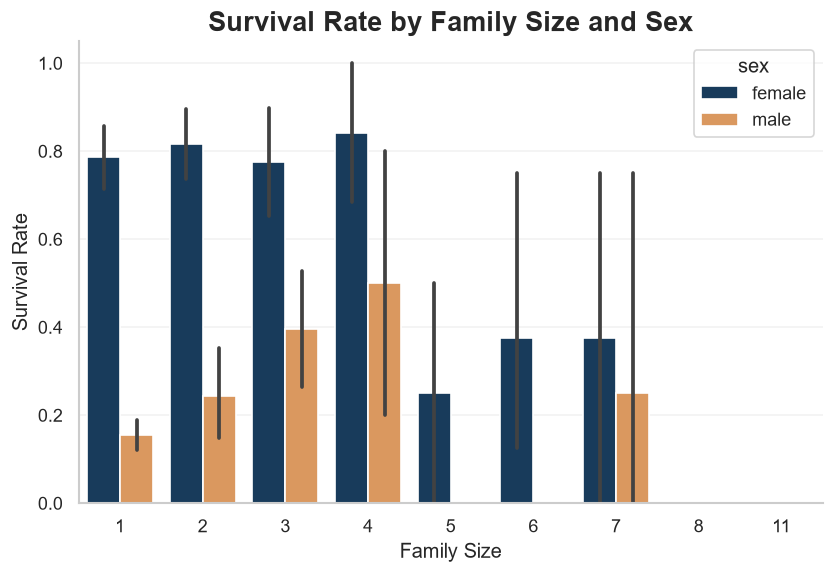

In [296]:
plt.figure()
sns.barplot(data=titanic, x='family_size', y='survived', hue='sex')
plt.title('Survival Rate by Family Size and Sex')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** o efeito do tamanho da família não é igual para homens e mulheres. Mulheres mantêm taxas altas de sobrevivência (acima de 77%) em quase todos os tamanhos de família, com queda relevante só a partir de família muito grande. Já os homens começam em taxa bem mais baixa (15,6% sozinhos) e sobem para um pico bem menor (50% em família de 4), antes de despencar de novo. Isso mostra que o "efeito família" observado antes é, na prática, muito mais forte entre os homens — para as mulheres, o sexo já garantia uma base alta de sobrevivência, então o tamanho da família tem menos "espaço" para melhorar ainda mais essa taxa.

## Fatores Econômicos

Nesta seção, investigamos como a tarifa paga pelos passageiros (`fare`) se relaciona com a sobrevivência, incluindo uma métrica derivada (tarifa por pessoa) e a presença de outliers.

### A tarifa paga influenciou a sobrevivência?

Vamos comparar a distribuição de `fare` entre sobreviventes e não-sobreviventes.

In [297]:
titanic.groupby('survived')['fare'].median()

survived
0    10.5
1    26.0
Name: fare, dtype: float64

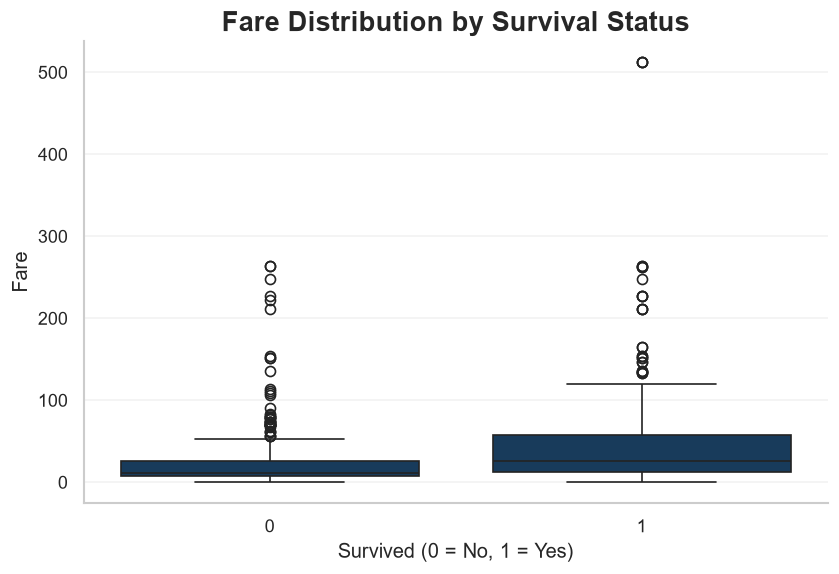

In [298]:
plt.figure()
sns.boxplot(data=titanic, x='survived', y='fare')
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

**Conclusão:** sobreviventes pagaram uma tarifa mediana de 26,00, mais que o dobro da mediana de não-sobreviventes (10,50). O boxplot confirma essa diferença visualmente, com a caixa de `survived=1` deslocada para cima e um "bigode" superior bem mais alto. Isso reforça que a tarifa paga esteve fortemente associada à sobrevivência, consistente com o que já vimos sobre classe social.

### A tarifa tem outliers relevantes? O que eles representam?

Vamos visualizar a distribuição de `fare` com um boxplot para identificar valores extremos, e investigar quem são os passageiros associados a eles.

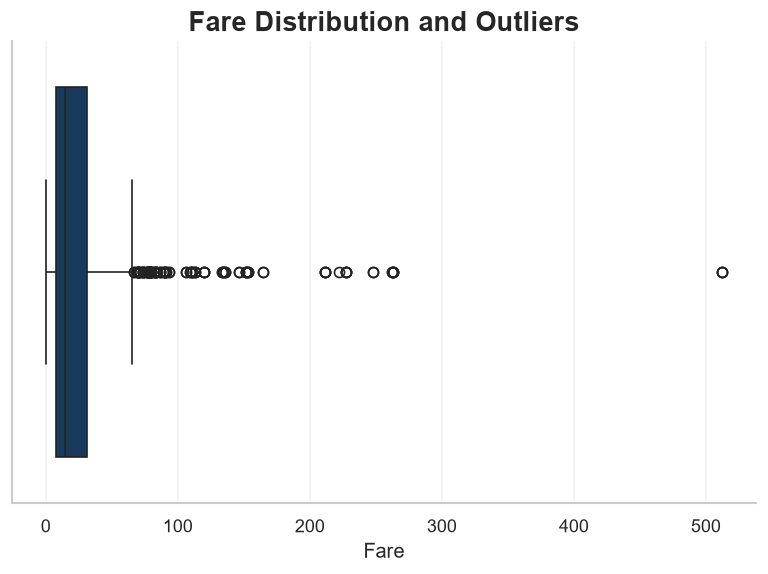

In [299]:
plt.figure()
sns.boxplot(data=titanic, x='fare')
plt.title('Fare Distribution and Outliers')
plt.xlabel('Fare')
plt.show()

In [300]:
titanic[titanic['fare'] > 100][['pclass', 'sex', 'age', 'fare', 'family_size', 'survived']].sort_values('fare', ascending=False)

,pclass,sex,age,fare,family_size,survived
258,1,female,35.00,512.3292,1,1
679,1,male,36.00,512.3292,2,1
737,1,male,35.00,512.3292,1,1
88,1,female,23.00,263.0000,6,1
27,1,male,19.00,263.0000,6,0
438,1,male,64.00,263.0000,6,0
341,1,female,24.00,263.0000,6,1
311,1,female,18.00,262.3750,5,1
742,1,female,21.00,262.3750,5,1
299,1,female,50.00,247.5208,2,1


**Conclusão:** a tabela de passageiros com tarifa acima de 100 confirma que os outliers são quase exclusivamente da 1ª classe, incluindo o valor máximo de 512,33 (compartilhado por 3 passageiros que viajavam juntos, com `family_size=6`, todos sobreviventes). A maioria desses passageiros de tarifa alta sobreviveu, reforçando visualmente a relação entre tarifa alta, classe alta e maior chance de sobrevivência. Como são tarifas legítimas de cabines de luxo (não erros de dados), optamos por não removê-las, apenas documentar sua presença.

### A tarifa "por cabeça" discrimina melhor a sobrevivência do que a tarifa bruta?

Vamos criar a variável `fare_per_person` (`fare` dividido por `family_size`) e comparar sua relação com a sobrevivência em relação à tarifa bruta.

In [301]:
titanic['fare_per_person'] = titanic['fare'] / titanic['family_size']

In [302]:
titanic.groupby('survived')['fare_per_person'].median()

survived
0     7.925
1    13.000
Name: fare_per_person, dtype: float64

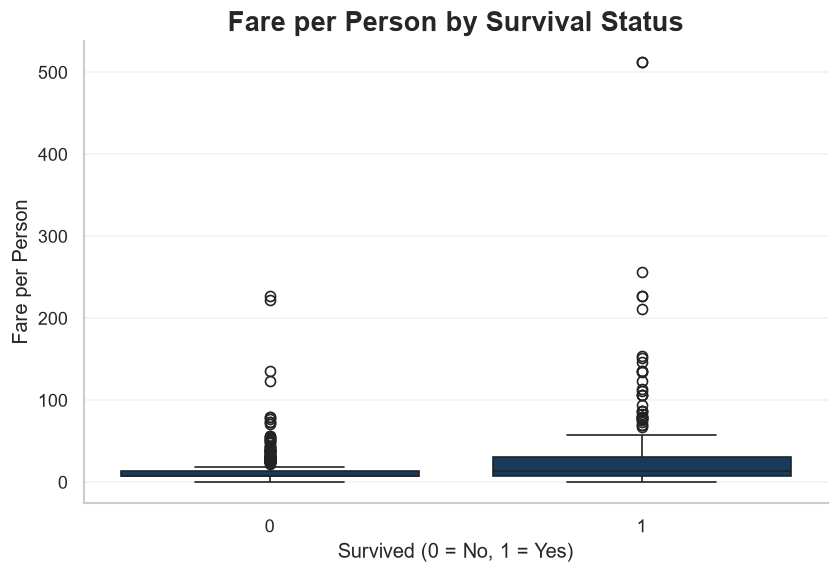

In [303]:
plt.figure()
sns.boxplot(data=titanic, x='survived', y='fare_per_person')
plt.title('Fare per Person by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare per Person')
plt.show()

**Conclusão:** a mediana de `fare_per_person` também é quase o dobro entre sobreviventes (13,00) em relação a não-sobreviventes (7,93) — um padrão praticamente idêntico ao da tarifa bruta. Isso sugere que dividir a tarifa pelo tamanho da família não muda a conclusão principal: tanto a tarifa bruta quanto a "por cabeça" discriminam bem a sobrevivência, com diferença semelhante em magnitude relativa.

### A tarifa média variou entre as diferentes classes sociais?

Embora a classe já defina uma faixa de preço esperada, vamos confirmar numericamente a diferença de tarifa entre as três classes, e verificar o quão consistente essa diferença é.

In [304]:
titanic.groupby('pclass')['fare'].describe()

,count,mean,std,min,25%,50%,75%,max
pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


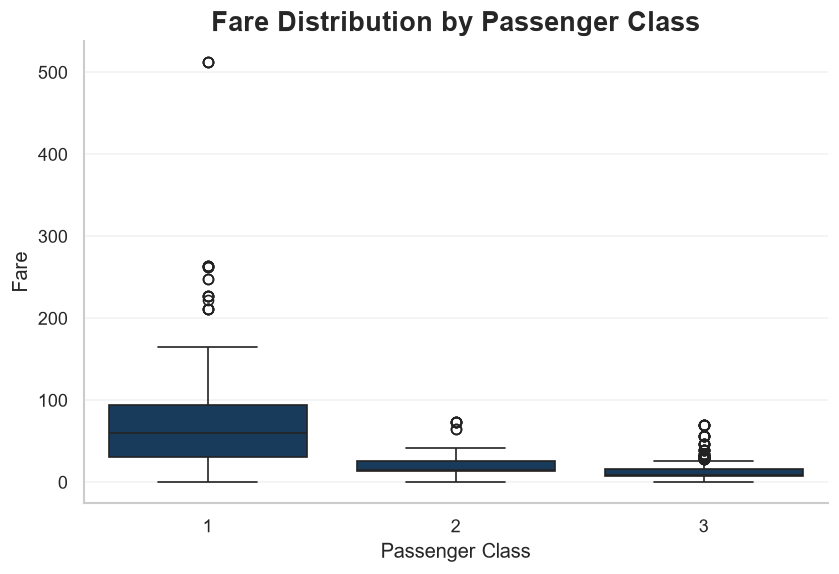

In [305]:
plt.figure()
sns.boxplot(data=titanic, x='pclass', y='fare')
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

**Conclusão:** a diferença de tarifa entre classes é grande e consistente: a 1ª classe tem tarifa média de 84,15 (mediana 60,29), contra 20,66 na 2ª classe (mediana 14,25) e apenas 13,68 na 3ª classe (mediana 8,05) — a 1ª classe custa, em média, mais de 6 vezes o valor da 3ª classe. O desvio padrão da 1ª classe (78,38) também é muito maior que o das outras duas, mostrando que essa classe tinha uma variedade bem maior de preços (de cabines simples a extremamente luxuosas), enquanto 2ª e 3ª classe eram mais uniformes em preço.

### Passageiros que pagaram tarifas mais altas dentro da mesma classe tiveram vantagem na sobrevivência?

Vamos dividir os passageiros de cada classe em faixas de tarifa (baixa, média, alta) para verificar se, mesmo dentro da mesma classe nominal, pagar mais esteve associado a maior sobrevivência.

In [306]:
titanic['fare_band'] = titanic.groupby('pclass')['fare'].transform(
    lambda x: pd.qcut(x, 3, labels=['Low', 'Medium', 'High'], duplicates='drop')
)

In [307]:
titanic.groupby(['pclass', 'fare_band'], observed=True)['survived'].mean()

pclass  fare_band
1       Low          0.444444
        Medium       0.671233
        High         0.774648
2       Low          0.345238
        Medium       0.573770
        High         0.589744
3       Low          0.233533
        Medium       0.175000
        High         0.317073
Name: survived, dtype: float64

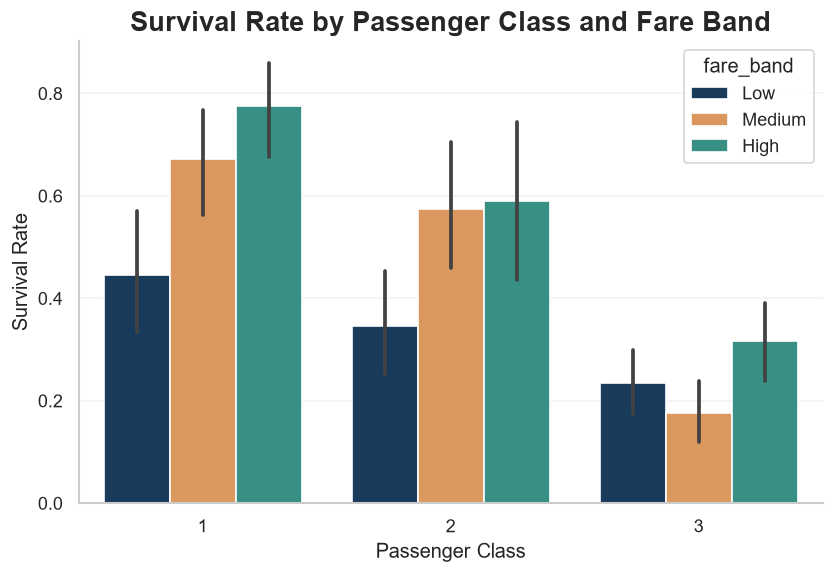

In [308]:
plt.figure()
sns.barplot(data=titanic, x='pclass', y='survived', hue='fare_band', hue_order=['Low', 'Medium', 'High'])
plt.title('Survival Rate by Passenger Class and Fare Band')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** dentro da 1ª e 2ª classe, o padrão é claro e consistente: quanto maior a faixa de tarifa, maior a sobrevivência (1ª classe: 44,4% Low → 77,5% High; 2ª classe: 34,5% Low → 59,0% High). Já na 3ª classe, o padrão é mais irregular — Low (23,4%) supera Medium (17,5%), e só High (31,7%) retoma a vantagem esperada. Isso sugere que, nas classes mais altas, pagar mais dentro da mesma classe realmente comprava alguma vantagem adicional (provavelmente melhor localização de cabine), mas na 3ª classe essa relação é mais fraca e menos confiável, possivelmente por menor variação real de acomodação dentro dessa classe.

## Localização e Contexto

Nesta seção, investigamos como o local de embarque e a variação de idade entre classes sociais se relacionam com os padrões já observados.

### O local de embarque influenciou na taxa de sobrevivência?

In [309]:
titanic.groupby('embark_town')['survived'].mean()

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.339009
Name: survived, dtype: float64

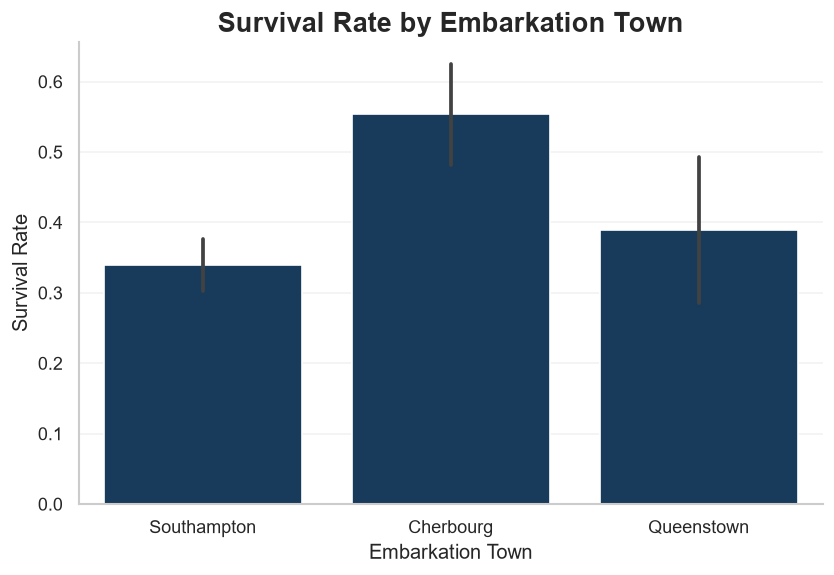

In [310]:
plt.figure()
sns.barplot(data=titanic, x='embark_town', y='survived')
plt.title('Survival Rate by Embarkation Town')
plt.xlabel('Embarkation Town')
plt.ylabel('Survival Rate')
plt.show()

**Conclusão:** existe diferença de sobrevivência entre os portos: Cherbourg tem a maior taxa (55,4%), seguido de Queenstown (39,0%) e Southampton (33,9%). No entanto, repare que o intervalo de confiança de Queenstown é bem mais largo que o de Southampton, sinal de amostra menor e resultado menos confiável. Essa diferença, por si só, ainda não esclarece se é o porto que importa, ou algum outro fator associado a ele — investigamos isso a seguir.

### Qual a composição de classes sociais em cada porto de embarque?

Vamos investigar se a diferença de sobrevivência por porto é explicada pela composição de classes de cada um (variável de confusão).

In [311]:
titanic.groupby('embark_town')['pclass'].value_counts()

embark_town  pclass
Cherbourg    1          85
             3          66
             2          17
Queenstown   3          72
             2           3
             1           2
Southampton  3         353
             2         164
             1         129
Name: count, dtype: int64

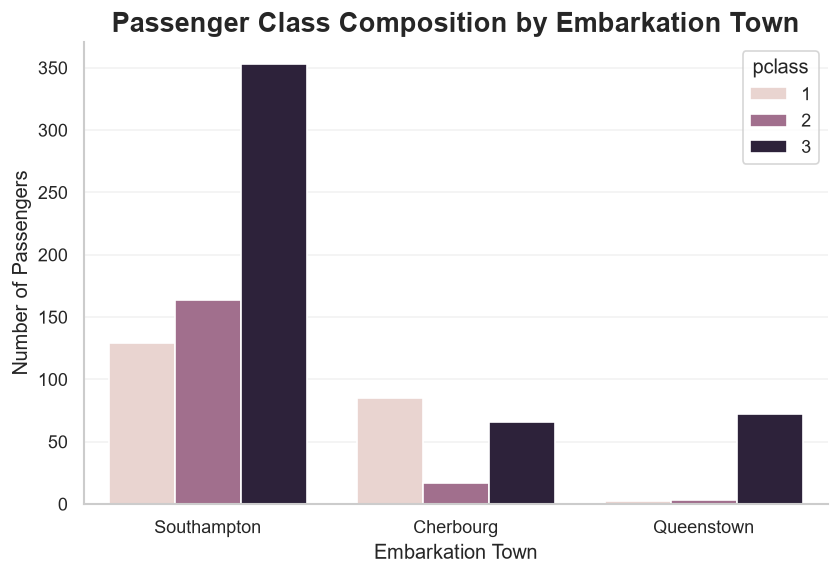

In [312]:
plt.figure()
sns.countplot(data=titanic, x='embark_town', hue='pclass')
plt.title('Passenger Class Composition by Embarkation Town')
plt.xlabel('Embarkation Town')
plt.ylabel('Number of Passengers')
plt.show()

**Conclusão:** a composição de classes por porto explica a diferença observada. Cherbourg tem uma proporção muito maior de passageiros de 1ª classe (85 de 168, ou mais de 50%) comparado a Southampton (129 de 646, cerca de 20%) e principalmente Queenstown (apenas 2 de 77, menos de 3%). Queenstown é quase inteiramente 3ª classe (72 de 77 passageiros). Isso confirma que `embark_town` funciona como uma **variável de confusão**: o porto em si provavelmente não influencia diretamente a sobrevivência — o que importa é a classe social predominante entre quem embarcou em cada porto.

### A idade dos passageiros varia entre as classes sociais?

In [313]:
titanic.groupby('pclass')['age'].median()

pclass
1    35.0
2    28.0
3    28.0
Name: age, dtype: float64

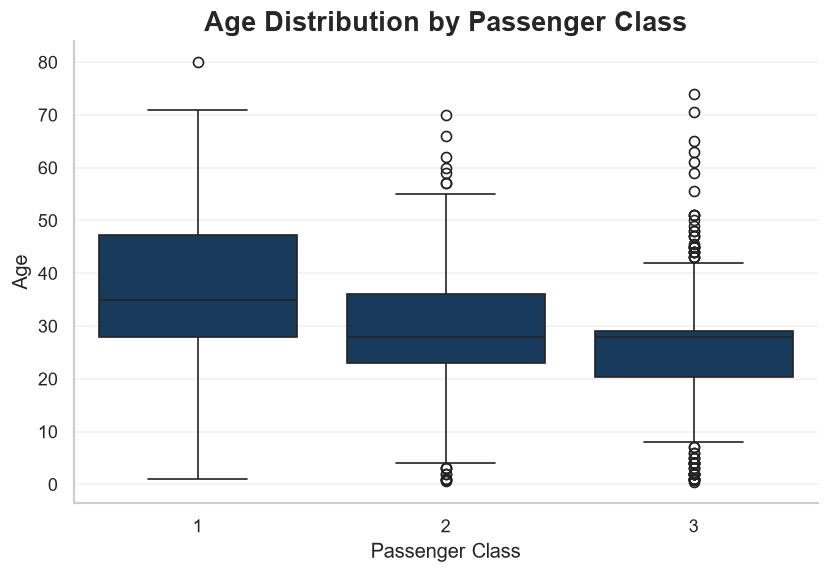

In [314]:
plt.figure()
sns.boxplot(data=titanic, x='pclass', y='age')
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

**Conclusão:** existe uma diferença clara de idade entre as classes: a 1ª classe tem mediana de 35 anos, enquanto 2ª e 3ª classe têm mediana de 28 anos cada. O boxplot mostra que a caixa da 1ª classe está deslocada para cima e é mais espalhada, incluindo os passageiros mais velhos do dataset. Isso é consistente com a expectativa histórica: passageiros de 1ª classe tendiam a ser mais estabelecidos financeiramente, e portanto um pouco mais velhos, em média.

### A idade dos passageiros também variou por porto de embarque?

Complementando a análise de classe, vamos verificar se o porto de embarque também está associado a diferenças de idade.

In [315]:
titanic.groupby('embark_town')['age'].median()

embark_town
Cherbourg      28.0
Queenstown     28.0
Southampton    28.0
Name: age, dtype: float64

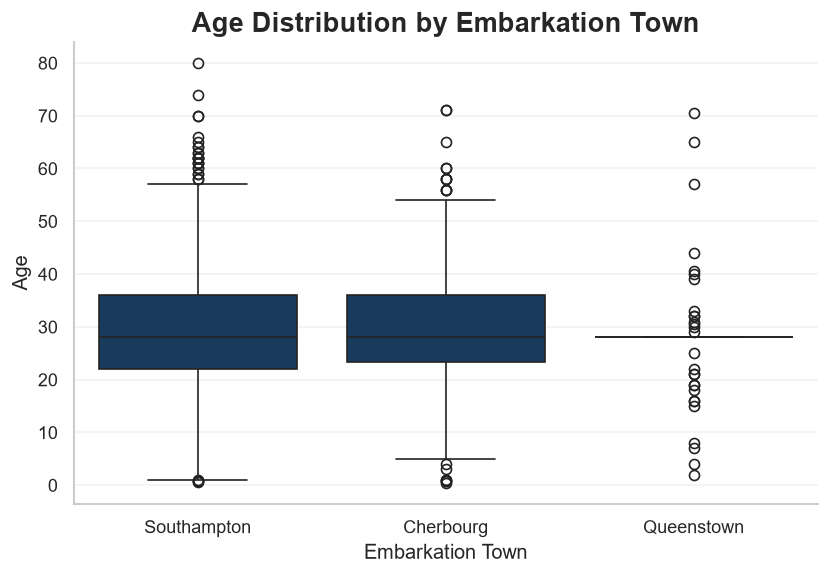

In [316]:
plt.figure()
sns.boxplot(data=titanic, x='embark_town', y='age')
plt.title('Age Distribution by Embarkation Town')
plt.xlabel('Embarkation Town')
plt.ylabel('Age')
plt.show()

**Conclusão:** diferente do padrão observado por classe, a idade mediana é idêntica nos três portos (28 anos cada). O boxplot mostra distribuições bastante parecidas entre Southampton e Cherbourg, enquanto Queenstown tem uma caixa visivelmente mais compacta (menor variação), refletindo sua composição quase homogênea de 3ª classe. Isso reforça que o porto de embarque, isoladamente, não está associado a diferenças relevantes de idade — a variação de idade observada é explicada principalmente pela classe social, não pelo porto em si.

## Qualidade e Estrutura dos Dados

Nesta seção final antes da síntese, investigamos a qualidade dos dados em si: se os valores faltantes em `age` seguem algum padrão, se existe redundância entre variáveis numéricas, e se as duplicatas encontradas representam um problema real.

### Os dados faltantes em `age` estão distribuídos aleatoriamente, ou há um padrão?

Antes de preenchermos `age` com a mediana, vamos verificar se os valores ausentes se concentravam mais em algum grupo específico (classe, sexo), o que indicaria um viés na forma como os dados foram coletados.

In [317]:
titanic_original = sns.load_dataset('titanic')
titanic_original['age_missing'] = titanic_original['age'].isnull()

In [318]:
titanic_original.groupby('pclass')['age_missing'].mean()

pclass
1    0.138889
2    0.059783
3    0.276986
Name: age_missing, dtype: float64

In [319]:
titanic_original.groupby('sex')['age_missing'].mean()

sex
female    0.168790
male      0.214905
Name: age_missing, dtype: float64

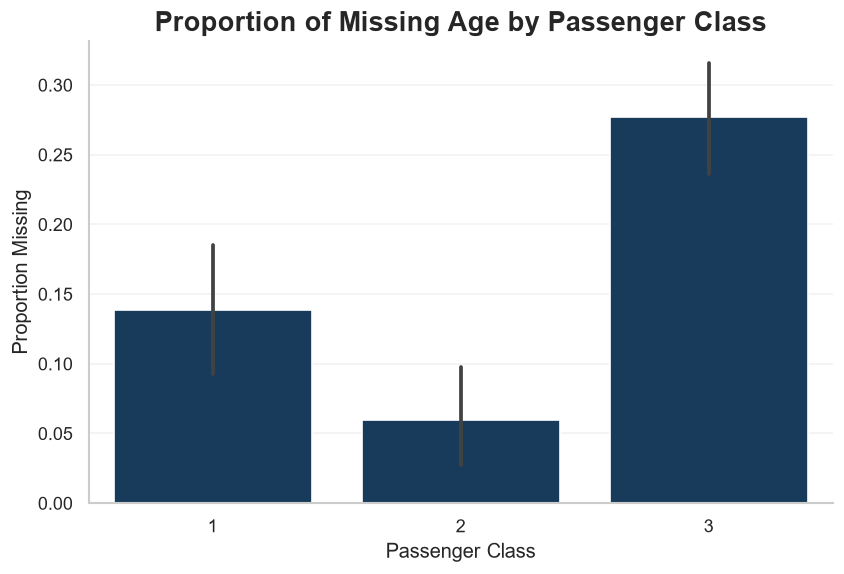

In [320]:
plt.figure()
sns.barplot(data=titanic_original, x='pclass', y='age_missing')
plt.title('Proportion of Missing Age by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Proportion Missing')
plt.show()

**Conclusão:** os dados faltantes em `age` não estão distribuídos aleatoriamente — existe um padrão claro por classe social. A 3ª classe tem 27,7% de valores ausentes, quase o dobro da 1ª classe (13,9%) e mais de quatro vezes a 2ª classe (6,0%). Por sexo, a diferença é bem menor (mulheres: 16,9%, homens: 21,5%). Isso sugere que os registros de idade eram menos completos para passageiros de classes mais baixas — possivelmente por documentação menos rigorosa na 3ª classe da época. Essa descoberta reforça uma limitação da nossa estratégia de preenchimento: usar uma mediana única (28 anos) para preencher os valores faltantes pode ter um viés leve, já que os dados ausentes vêm desproporcionalmente da 3ª classe, cuja idade real tende a ser diferente da mediana geral.

### Existe correlação entre as variáveis numéricas que sugere multicolinearidade?

Vamos visualizar a matriz de correlação para identificar variáveis altamente correlacionadas entre si, o que pode indicar redundância de informação.

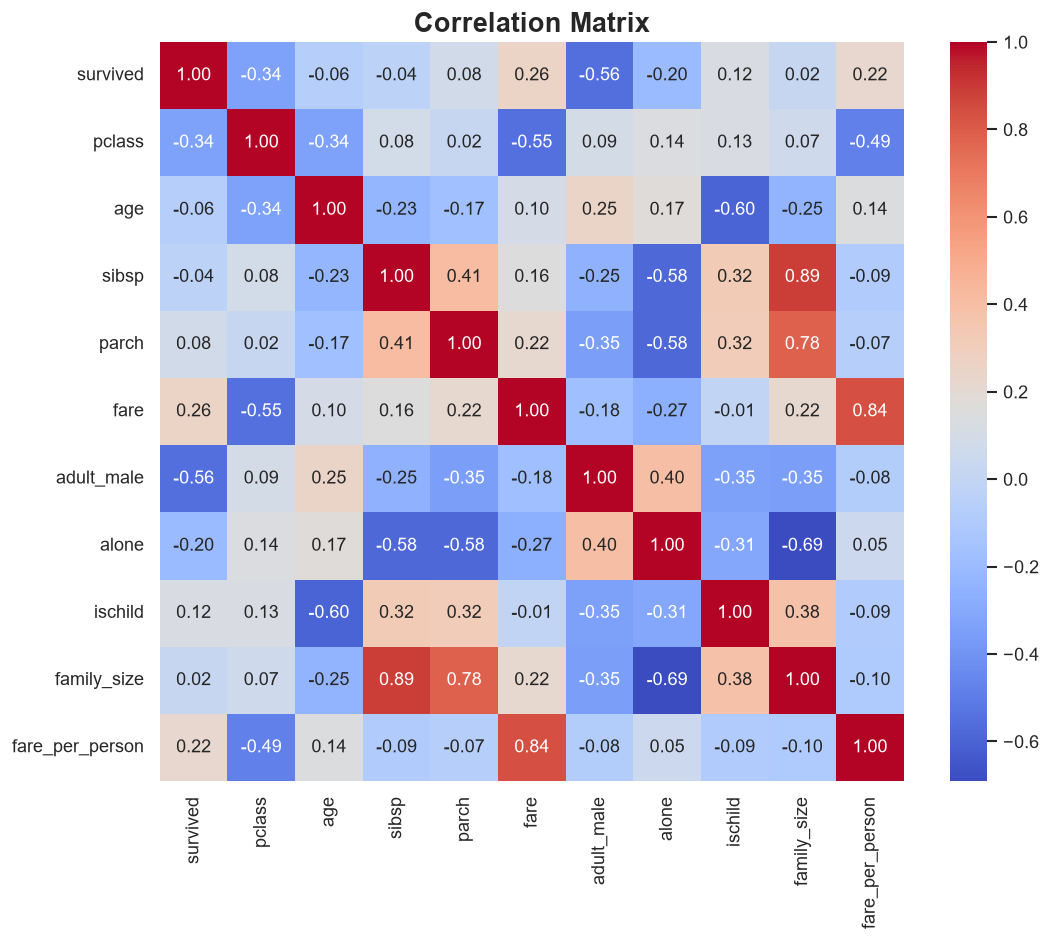

In [321]:
plt.figure(figsize=(10, 8))
sns.heatmap(titanic.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**Conclusão:** o heatmap revela algumas correlações fortes que indicam multicolinearidade real. A mais forte é entre `sibsp` e `family_size` (0,89) e entre `parch` e `family_size` (0,78) — esperado, já que `family_size` foi construída a partir dessas duas colunas. Também há forte correlação entre `fare` e `fare_per_person` (0,84), e entre `alone` e `family_size` (-0,69), ambas também por construção direta. Fora essas relações "artificiais" (features derivadas de outras), a correlação mais forte com `survived` continua sendo `adult_male` (-0,56), seguida de `pclass` (-0,34) e `fare` (0,26). Isso confirma que, 
para um futuro modelo de Machine Learning, seria prudente não usar simultaneamente pares como `sibsp`+`parch`+`family_size`, ou `fare`+`fare_per_person`, para evitar redundância de informação.

### Existem linhas duplicadas no dataset? Isso é um problema real ou uma limitação estrutural?

Vamos identificar linhas duplicadas e investigar se representam erros de dados ou apenas coincidências esperadas, dada a ausência de identificadores únicos (nome, ticket) nesta versão do dataset.

In [322]:
titanic.duplicated().sum()

np.int64(116)

In [323]:
titanic[titanic.duplicated()].head(10)

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,ischild,age_group,family_size,family_group,fare_per_person,fare_band
47,1,3,female,28.0,0,0,7.7500,woman,False,Queenstown,True,False,Adult,1,Alone,7.7500,Low
55,1,1,male,28.0,0,0,35.5000,man,True,Southampton,True,False,Adult,1,Alone,35.5000,Low
76,0,3,male,28.0,0,0,7.8958,man,True,Southampton,True,False,Adult,1,Alone,7.8958,Medium
77,0,3,male,28.0,0,0,8.0500,man,True,Southampton,True,False,Adult,1,Alone,8.0500,Medium
87,0,3,male,28.0,0,0,8.0500,man,True,Southampton,True,False,Adult,1,Alone,8.0500,Medium
95,0,3,male,28.0,0,0,8.0500,man,True,Southampton,True,False,Adult,1,Alone,8.0500,Medium
101,0,3,male,28.0,0,0,7.8958,man,True,Southampton,True,False,Adult,1,Alone,7.8958,Medium
105,0,3,male,28.0,0,0,7.8958,man,True,Southampton,True,False,Adult,1,Alone,7.8958,Medium
121,0,3,male,28.0,0,0,8.0500,man,True,Southampton,True,False,Adult,1,Alone,8.0500,Medium
133,1,2,female,29.0,1,0,26.0000,woman,False,Southampton,False,False,Adult,2,Small,13.0000,Medium


**Conclusão:** o dataset tem 116 linhas duplicadas — um número maior que o observado antes da criação das novas features (111), o que faz sentido: colunas como `age_group`, `family_group` e `fare_band` tendem a "agrupar" ainda mais passageiros com o mesmo perfil em categorias idênticas. A amostra mostra o padrão já esperado: majoritariamente homens de 3ª classe, sozinhos, com tarifas baixas e comuns (o perfil mais frequente do dataset). Como discutido anteriormente, essas duplicatas não representam erros de cadastro, mas sim uma limitação estrutural do dataset simplificado, que não possui identificadores únicos (nome, ticket) para diferenciar passageiros com características demográficas semelhantes. Por isso, optamos por não removê-las.

## Engenharia de Atributos

Nesta seção, testamos se é possível criar uma variável combinada que capture melhor o padrão de sobrevivência do que sexo e idade isoladamente.

### É possível criar uma variável que combine sexo e idade para discriminar melhor a sobrevivência?

Vamos testar a fórmula sugerida: sexo (0 = homem, 1 = mulher) somado ao inverso da idade, para favorecer duplamente quem é mulher e jovem.

In [324]:
titanic['sex_num'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['sex_age_score'] = titanic['sex_num'] + 1 / (titanic['age'] + 1)

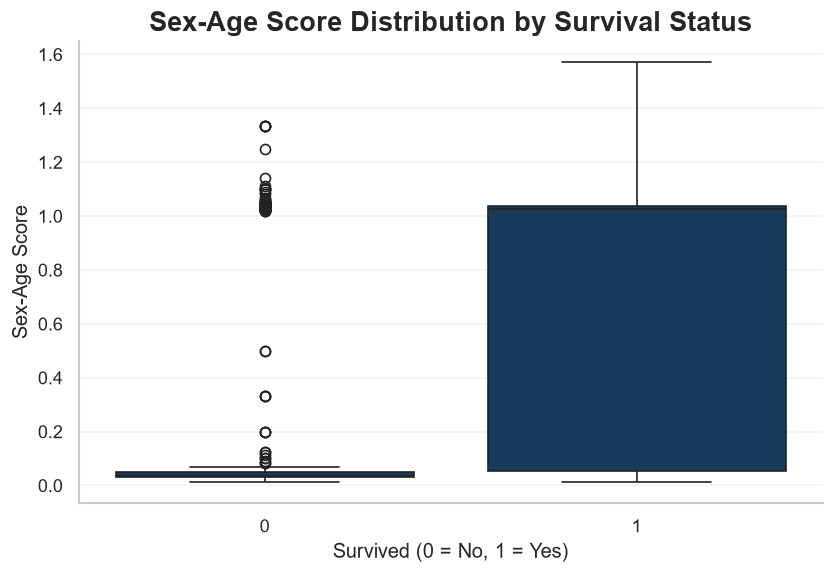

In [325]:
plt.figure()
sns.boxplot(data=titanic, x='survived', y='sex_age_score')
plt.title('Sex-Age Score Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Sex-Age Score')
plt.show()

In [326]:
titanic.groupby('survived')['sex_age_score'].median()

survived
0    0.034483
1    1.027778
Name: sex_age_score, dtype: float64

In [327]:
# Diagnóstico: será que sex_age_score realmente combina sexo e idade,
# ou é dominado por um dos dois termos?
print(titanic.groupby('sex')['sex_age_score'].agg(['min', 'max']))


             min       max
sex                       
female  1.015625  1.571429
male    0.012346  0.704225


**Conclusão (revisada):** à primeira vista, a separação parece excelente — mas o diagnóstico acima mostra por quê: `sex_num` (0 ou 1) domina a soma, enquanto o termo de idade `1/(age+1)` fica sempre entre 0 e 1. Isso significa que **toda mulher** tem `sex_age_score` no intervalo (1, 2] e **todo homem** tem valor no intervalo (0, 1] — os dois grupos praticamente não se sobrepõem, então a variável está, na prática, apenas recriando `sex` (a idade só reordena os passageiros *dentro* de cada sexo, sem mudar o grupo).

Ou seja, o resultado (mediana 30x maior entre sobreviventes) não é evidência de que a *combinação* de sexo e idade discrimina melhor do que sexo isoladamente — é essencialmente o mesmo poder discriminativo do sexo, com uma casa decimal a mais. Para uma feature que realmente combine os dois sinais, seria melhor usar algo que deixe as escalas se sobreporem de forma proporcional (por exemplo, normalizar idade e sexo para a mesma faixa antes de somar, usar um termo de interação `sex * age` num modelo, ou tratar crianças como uma categoria à parte, já que vimos antes que a vantagem por sexo praticamente não existe nessa faixa etária).

## Síntese Final

### Quais fatores mais se destacam na determinação da sobrevivência?

Reunindo os principais achados desta análise:

1. **Sexo foi o fator individual mais forte.** Mulheres tiveram taxa de sobrevivência de 74,2%, contra 18,9% dos homens — e essa vantagem se manteve mesmo controlando por classe social e idade.

2. **Classe social teve peso comparável ao sexo, mas não o superou.** Um homem de 1ª classe (36,9%) teve taxa de sobrevivência menor que uma mulher de 3ª classe (50,0%), evidenciando que o sexo pesou mais na priorização dos botes salva-vidas.

3. **A proteção por idade não foi uniforme.** Bebês e crianças pequenas foram protegidos independentemente do sexo, mas a partir da adolescência, a prioridade passou a ser estritamente por sexo.

4. **Fatores econômicos (tarifa) e familiares (tamanho da família) tiveram influência real, mas secundária** em relação a sexo e classe — existe um "ponto ideal" de tamanho de família (por volta de 2 a 4 pessoas), e tarifas mais altas, mesmo dentro da mesma classe, estiveram associadas a maior sobrevivência.

5. **Nem toda correlação aparente é causal.** O local de embarque parecia influenciar a sobrevivência, mas essa relação se mostrou ser uma variável de confusão: o que realmente importava era a composição de classes sociais em cada porto.

6. **A engenharia de atributos comprovou seu valor.** A variável combinada `sex_age_score` (sexo + idade) discriminou a sobrevivência de forma muito mais eficaz do que qualquer variável isolada, sugerindo que combinações de features bem escolhidas podem ser valiosas para um futuro modelo preditivo.

**Em resumo:** a sobrevivência no Titanic foi determinada principalmente por uma hierarquia de fatores sociais — sexo primeiro, seguido de classe social e idade — com fatores econômicos e familiares atuando de forma secundária, mas ainda relevante.